# Preprocessing & Augmentation Pipeline (Crack Detection)



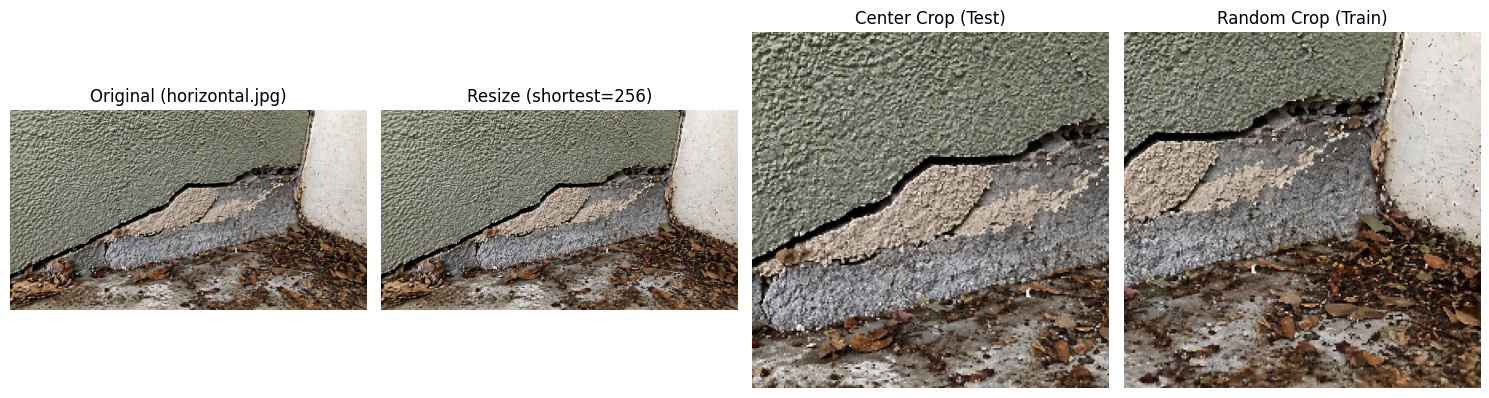

In [18]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

IMG_SIZE = 224
RESIZE_SIZE = 256

def resize_preserve_aspect(img, target_size=256):
    shape = tf.shape(img)
    h, w = shape[0], shape[1]

    # Calculate scale to make shortest side = target_size
    scale = tf.cast(target_size, tf.float32) / tf.cast(tf.minimum(h, w), tf.float32)

    new_h = tf.cast(tf.round(tf.cast(h, tf.float32) * scale), tf.int32)
    new_w = tf.cast(tf.round(tf.cast(w, tf.float32) * scale), tf.int32)

    return tf.image.resize(img, [new_h, new_w])


# Load image (Using horizontal.jpg instead of missing test.jpg)
image_path = "horizontal.jpg"
if not os.path.exists(image_path):
    # Fallback to any available jpg if horizontal is missing
    jpg_files = [f for f in os.listdir('.') if f.endswith('.jpg')]
    if jpg_files:
        image_path = jpg_files[0]

img_raw = tf.io.read_file(image_path)
img_raw = tf.image.decode_image(img_raw, channels=3, expand_animations=False)
img_raw.set_shape([None, None, 3]) # Ensure rank 3 for processing

# 🔥 Resize preserve ratio
img_resize = resize_preserve_aspect(img_raw, RESIZE_SIZE)

# 🔥 Center crop (test)
img_center_crop = tf.image.resize_with_crop_or_pad(img_resize, IMG_SIZE, IMG_SIZE)

# 🔥 Random crop (train)
img_random_crop = tf.image.random_crop(img_resize, size=[IMG_SIZE, IMG_SIZE, 3])


# ================= VISUAL =================
plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.title(f"Original ({image_path})")
plt.imshow(img_raw.numpy().astype("uint8"))
plt.axis("off")

plt.subplot(1,4,2)
plt.title("Resize (shortest=256)")
plt.imshow(img_resize.numpy().astype("uint8"))
plt.axis("off")

plt.subplot(1,4,3)
plt.title("Center Crop (Test)")
plt.imshow(img_center_crop.numpy().astype("uint8"))
plt.axis("off")

plt.subplot(1,4,4)
plt.title("Random Crop (Train)")
plt.imshow(img_random_crop.numpy().astype("uint8"))
plt.axis("off")

plt.tight_layout()
plt.show()